In [25]:
# Notebook 02: Data Cleaning
# WHY we load from RAW: To show full BEFORE → AFTER story
# We keep _raw copies untouched for BEFORE visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

RAW_DATA_PATH       = os.path.join('..', 'data', 'raw')
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
EXPORTS_PATH        = os.path.join('..', 'exports')
os.makedirs(EXPORTS_PATH, exist_ok=True)

# Load both raw files — keep permanent snapshots
posoco_raw = pd.read_csv(os.path.join(RAW_DATA_PATH, 'POSOCO_data.csv'))
posoco     = posoco_raw.copy()  # this gets cleaned

cea_raw    = pd.read_csv(os.path.join(RAW_DATA_PATH, 'CEA_DGR_data.csv'))
cea        = cea_raw.copy()     # this gets cleaned

print("=== RAW DATA LOADED ===")
print(f"POSOCO : {posoco_raw.shape} | nulls: {posoco_raw.isnull().sum().sum()}")
print(f"CEA    : {cea_raw.shape}   | nulls: {cea_raw.isnull().sum().sum()}")
print("\nposoco_raw = permanent BEFORE snapshot ")
print("posoco     = will be cleaned ")
print("cea_raw    = permanent BEFORE snapshot ")
print("cea        = will be cleaned ")

=== RAW DATA LOADED ===
POSOCO : (4828, 139) | nulls: 146835
CEA    : (2912, 17)   | nulls: 2888

posoco_raw = permanent BEFORE snapshot 
posoco     = will be cleaned 
cea_raw    = permanent BEFORE snapshot 
cea        = will be cleaned 


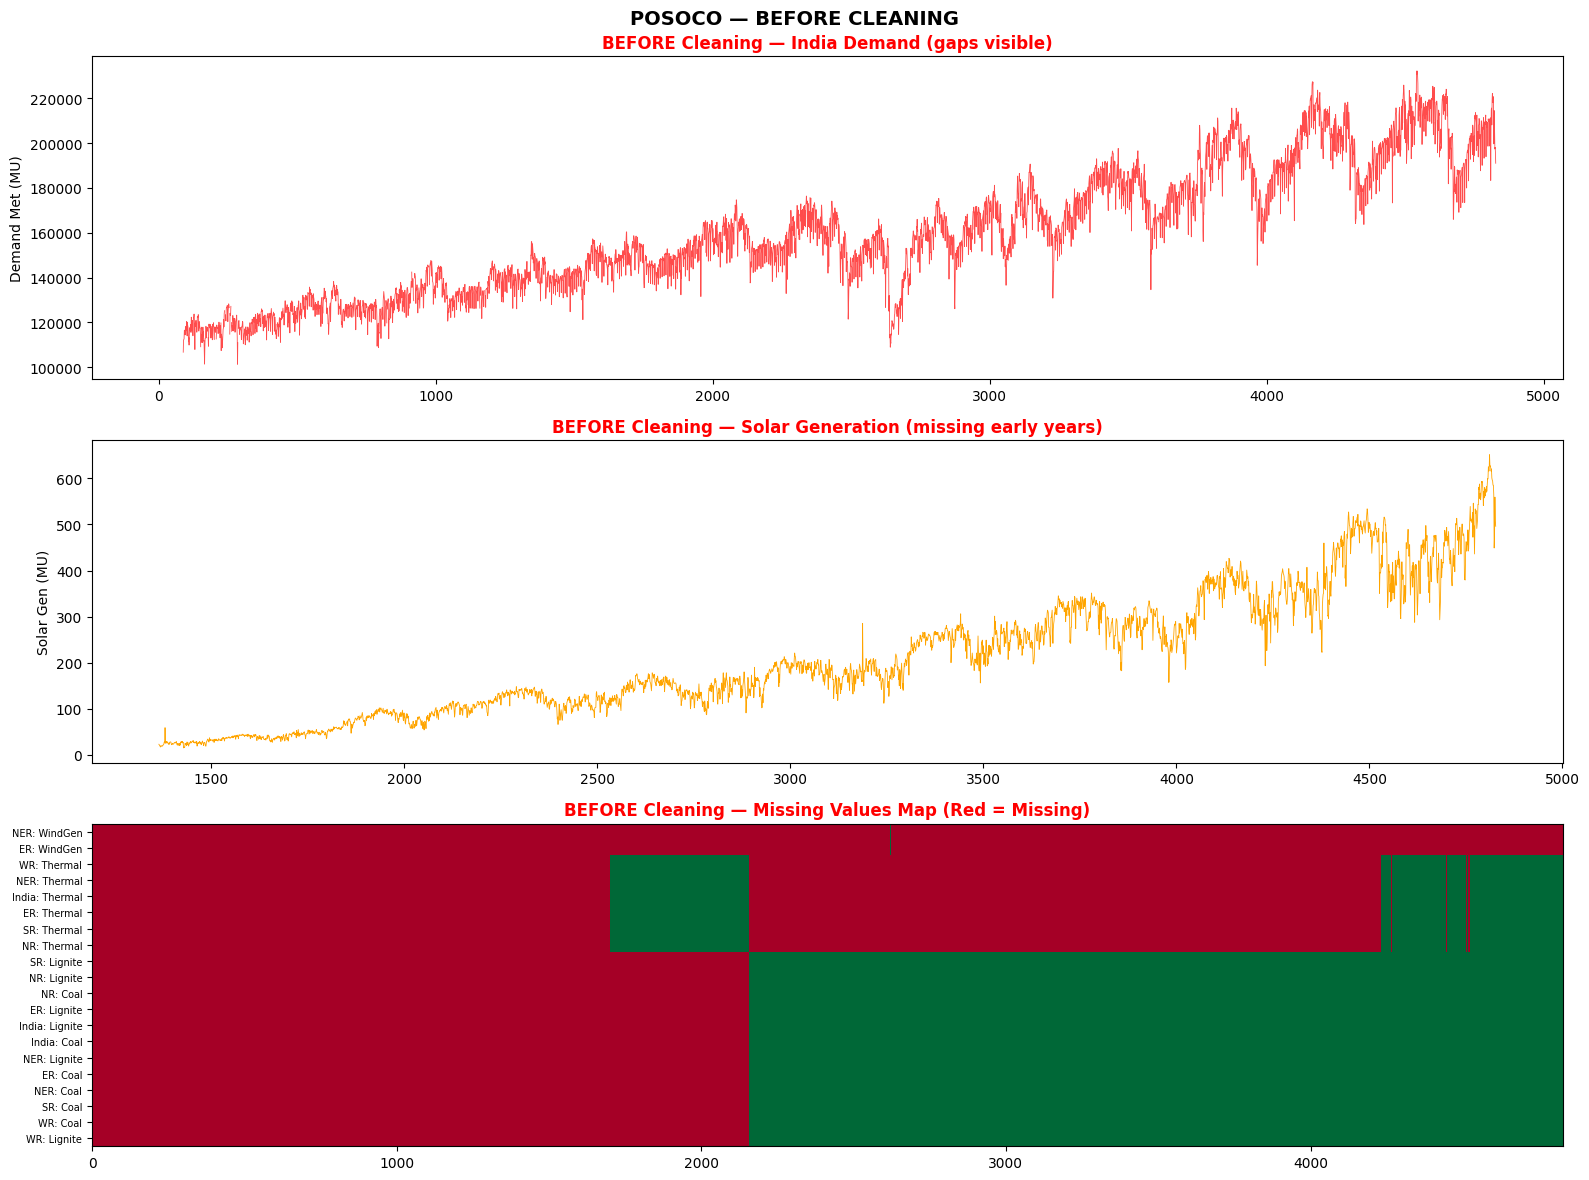

 Saved: 00_BEFORE_cleaning_posoco.png


In [26]:
# BEFORE CLEANING VISUALIZATION
# OPERATION: Plot raw POSOCO data problems visually
# WHY: Numbers alone don't prove the problem.
#      A chart showing gaps and missing periods is visual proof
#      of exactly WHY cleaning was necessary.

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1 — Demand with gaps
axes[0].plot(range(len(posoco_raw)),
             posoco_raw['India: DemandMet'],
             color='red', linewidth=0.6, alpha=0.7)
axes[0].set_title('BEFORE Cleaning — India Demand (gaps visible)',
                  fontweight='bold', color='red')
axes[0].set_ylabel('Demand Met (MU)')

# Plot 2 — Solar with missing early years
axes[1].plot(range(len(posoco_raw)),
             posoco_raw['India: SolarGen'],
             color='orange', linewidth=0.6)
axes[1].set_title('BEFORE Cleaning — Solar Generation (missing early years)',
                  fontweight='bold', color='red')
axes[1].set_ylabel('Solar Gen (MU)')

# Plot 3 — Missing values heatmap
top_missing = posoco_raw.isnull().sum()\
              .sort_values(ascending=False).head(20).index
missing_matrix = posoco_raw[top_missing].isnull().astype(int)
axes[2].imshow(missing_matrix.T, aspect='auto',
               cmap='RdYlGn_r', interpolation='none')
axes[2].set_title('BEFORE Cleaning — Missing Values Map (Red = Missing)',
                  fontweight='bold', color='red')
axes[2].set_yticks(range(len(top_missing)))
axes[2].set_yticklabels(top_missing, fontsize=7)

plt.suptitle('POSOCO — BEFORE CLEANING', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '00_BEFORE_cleaning_posoco.png'), dpi=150)
plt.show()
print(" Saved: 00_BEFORE_cleaning_posoco.png")

In [27]:
# BEFORE: Date stored as integer e.g. 20130102
# OPERATION: Convert to datetime
# WHY: Pandas cannot do time-series operations on integers.
#      Must be datetime64 for sorting, plotting, resampling.

print("=== BEFORE DATE CONVERSION ===")
print(f"dtype        : {posoco['yyyymmdd'].dtype}")
print(f"Sample value : {posoco['yyyymmdd'].iloc[0]}")

posoco['yyyymmdd'] = pd.to_datetime(posoco['yyyymmdd'], format='%Y%m%d')

print("\n=== AFTER DATE CONVERSION ===")
print(f"dtype        : {posoco['yyyymmdd'].dtype}")
print(f"Sample value : {posoco['yyyymmdd'].iloc[0]}")
print(f"Min date     : {posoco['yyyymmdd'].min()}")
print(f"Max date     : {posoco['yyyymmdd'].max()}")

=== BEFORE DATE CONVERSION ===
dtype        : int64
Sample value : 20130102

=== AFTER DATE CONVERSION ===
dtype        : datetime64[ns]
Sample value : 2013-01-02 00:00:00
Min date     : 2013-01-02 00:00:00
Max date     : 2026-03-22 00:00:00


In [28]:
# BEFORE: 146,835 nulls — three different patterns
# OPERATION: Three strategies based on null type
# WHY:
#   Solar/Shortage/MaxDemand/Peak → fill with 0
#   REASON: Not recorded yet, absence = zero not missing
#
#   Small gaps (~2.3%) → forward fill
#   REASON: Time series — yesterday's value best estimate
#
#   Generation columns (35-54%) → fill with 0
#   REASON: Data collection started later, no previous value exists

print("=== BEFORE NULL FILLING ===")
print(f"Total nulls: {posoco.isnull().sum().sum()}")

# Strategy 1: Zero fill
solar_cols    = [c for c in posoco.columns if 'SolarGen' in c]
shortage_cols = [c for c in posoco.columns if 'EnergyShortage' in c]
maxdem_cols   = [c for c in posoco.columns if 'MaximumDemand' in c]
peak_cols     = [c for c in posoco.columns if 'PeakShortage' in c]
zero_cols     = solar_cols + shortage_cols + maxdem_cols + peak_cols
posoco[zero_cols] = posoco[zero_cols].fillna(0)
print(f"After zero-fill  : {posoco.isnull().sum().sum()} nulls")

# Strategy 2: Forward fill
posoco = posoco.ffill()
print(f"After ffill      : {posoco.isnull().sum().sum()} nulls")

# Strategy 3: Backward fill
posoco = posoco.bfill()
print(f"After bfill      : {posoco.isnull().sum().sum()} nulls")

# Strategy 4: Fill any remaining with 0
posoco = posoco.fillna(0)

print(f"\n=== AFTER NULL FILLING ===")
print(f"Total nulls: {posoco.isnull().sum().sum()}")
print(" All nulls handled!" if posoco.isnull().sum().sum() == 0 else "⚠️ Still has nulls")

=== BEFORE NULL FILLING ===
Total nulls: 146835
After zero-fill  : 119007 nulls
After ffill      : 92284 nulls
After bfill      : 0 nulls

=== AFTER NULL FILLING ===
Total nulls: 0
 All nulls handled!


In [29]:
# OPERATION: Rename date column, set as index, save
# WHY: Date as index is standard for time-series data.
#      Saving to processed/ means raw data is never touched again.

posoco = posoco.rename(columns={'yyyymmdd': 'Date'})
posoco = posoco.set_index('Date')
posoco.to_csv(os.path.join(PROCESSED_DATA_PATH, 'posoco_cleaned.csv'))

print("=== POSOCO SAVE CONFIRMATION ===")
print(f"Shape      : {posoco.shape}")
print(f"Index      : {posoco.index.name} | {posoco.index.dtype}")
print(f"Nulls      : {posoco.isnull().sum().sum()}")
print(" posoco_cleaned.csv saved!")

=== POSOCO SAVE CONFIRMATION ===
Shape      : (4828, 138)
Index      : Date | datetime64[ns]
Nulls      : 0
 posoco_cleaned.csv saved!


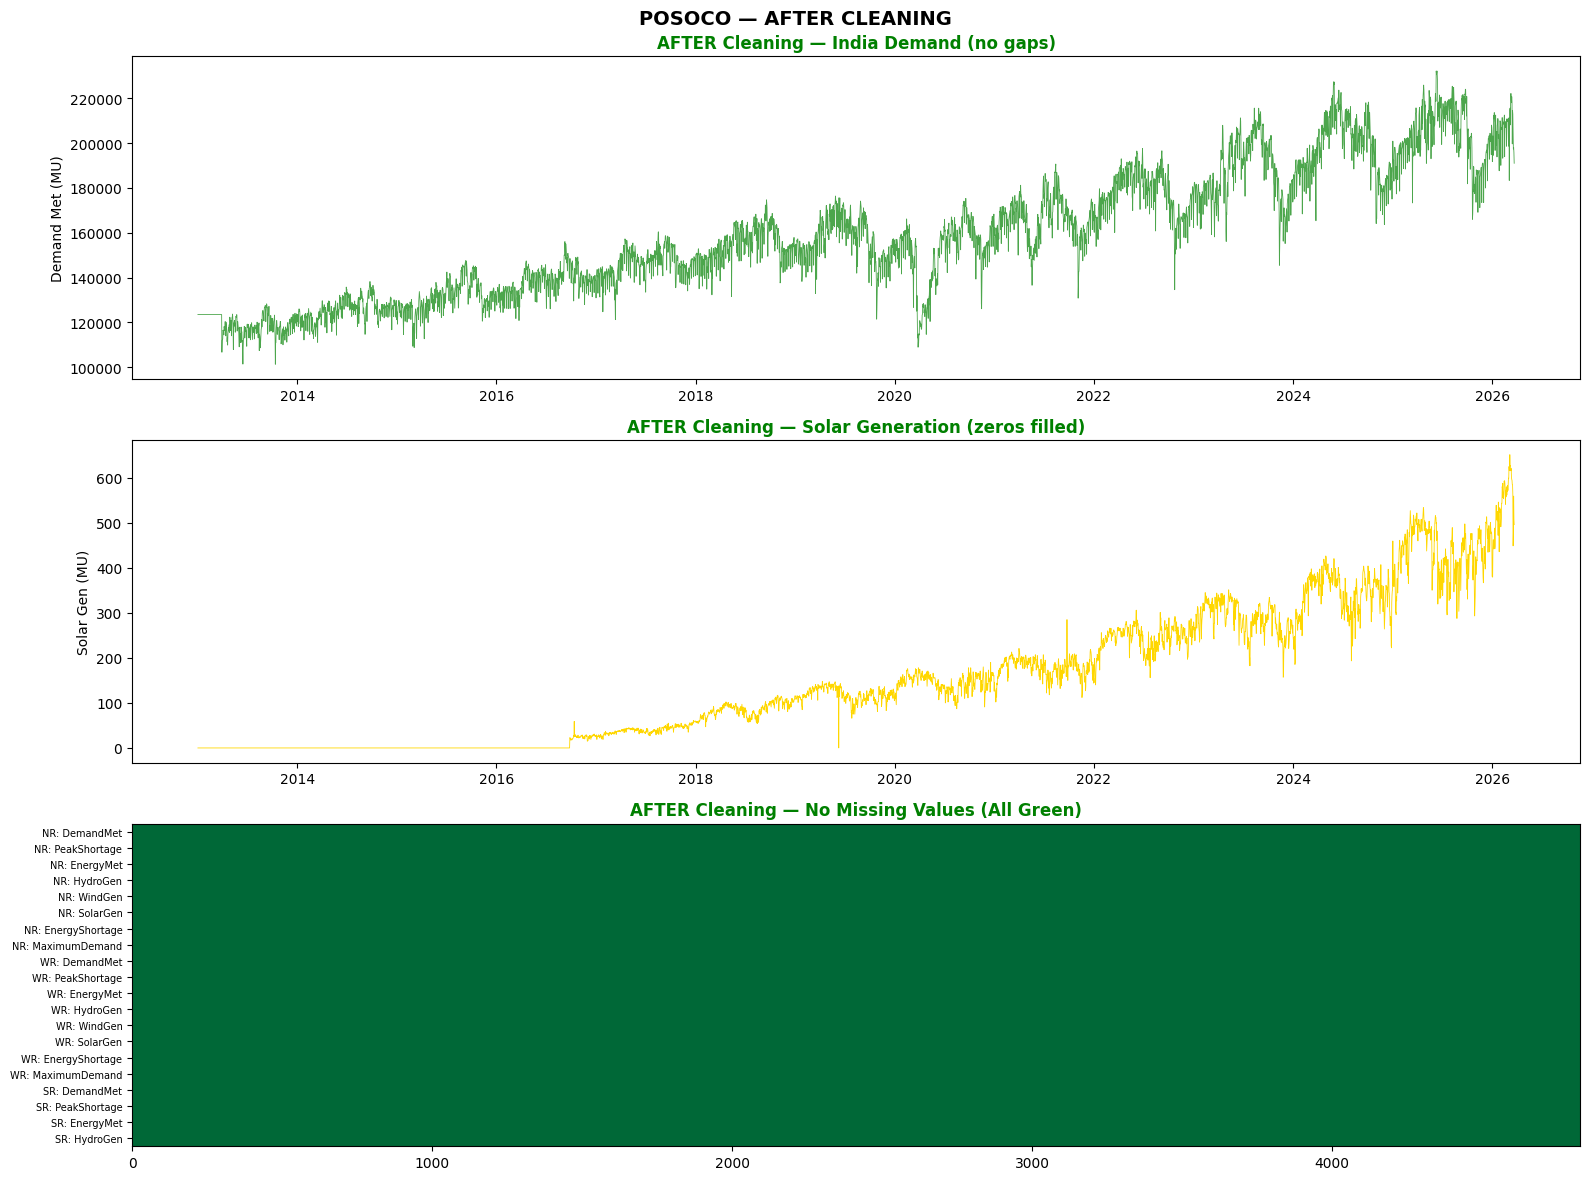

 Saved: 00_AFTER_cleaning_posoco.png


In [30]:
# AFTER CLEANING VISUALIZATION
# OPERATION: Same 3 plots on cleaned data
# WHY: Side by side with BEFORE proves cleaning worked.
#      Continuous green lines vs gappy red lines = clear proof.

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1 — Demand now complete
axes[0].plot(posoco.index, posoco['India: DemandMet'],
             color='green', linewidth=0.6, alpha=0.7)
axes[0].set_title('AFTER Cleaning — India Demand (no gaps)',
                  fontweight='bold', color='green')
axes[0].set_ylabel('Demand Met (MU)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2 — Solar now filled
axes[1].plot(posoco.index, posoco['India: SolarGen'],
             color='gold', linewidth=0.6)
axes[1].set_title('AFTER Cleaning — Solar Generation (zeros filled)',
                  fontweight='bold', color='green')
axes[1].set_ylabel('Solar Gen (MU)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 3 — No missing values
top_cols      = posoco.columns[:20]
missing_after = posoco[top_cols].isnull().astype(int)
axes[2].imshow(missing_after.T, aspect='auto',
               cmap='RdYlGn_r', interpolation='none')
axes[2].set_title('AFTER Cleaning — No Missing Values (All Green)',
                  fontweight='bold', color='green')
axes[2].set_yticks(range(len(top_cols)))
axes[2].set_yticklabels(top_cols, fontsize=7)

plt.suptitle('POSOCO — AFTER CLEANING', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '00_AFTER_cleaning_posoco.png'), dpi=150)
plt.show()
print(" Saved: 00_AFTER_cleaning_posoco.png")

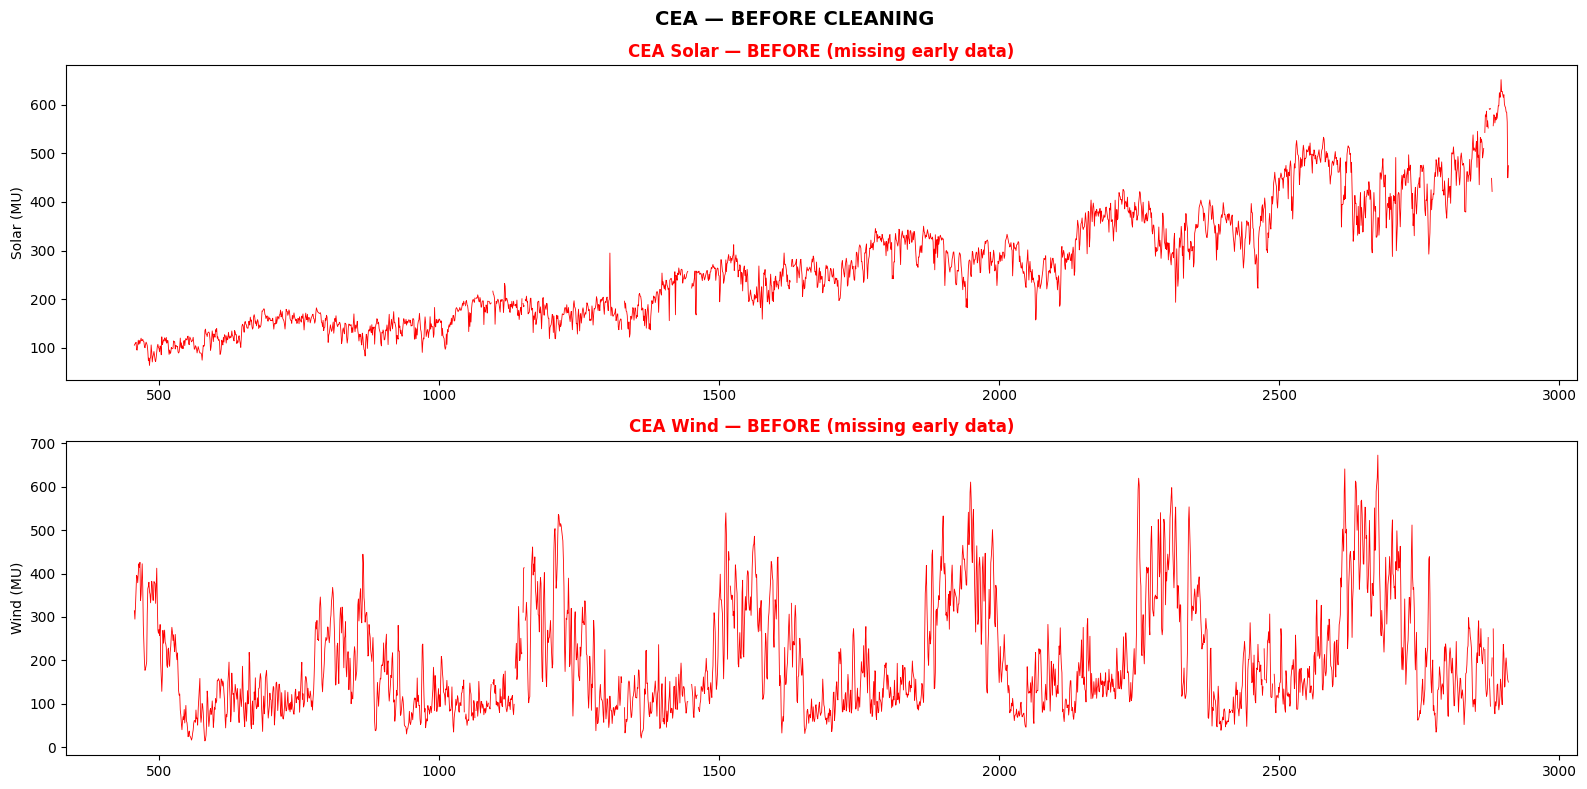

 Saved: 00_BEFORE_cleaning_cea.png


In [31]:
# CEA BEFORE CLEANING VISUALIZATION
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(range(len(cea_raw)), cea_raw['CEA.DGR.SOL'],
             color='red', linewidth=0.6)
axes[0].set_title('CEA Solar — BEFORE (missing early data)',
                  fontweight='bold', color='red')
axes[0].set_ylabel('Solar (MU)')

axes[1].plot(range(len(cea_raw)), cea_raw['CEA.DGR.WND'],
             color='red', linewidth=0.6)
axes[1].set_title('CEA Wind — BEFORE (missing early data)',
                  fontweight='bold', color='red')
axes[1].set_ylabel('Wind (MU)')

plt.suptitle('CEA — BEFORE CLEANING', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '00_BEFORE_cleaning_cea.png'), dpi=150)
plt.show()
print(" Saved: 00_BEFORE_cleaning_cea.png")

In [32]:
# CEA DATE CONVERSION
# BEFORE: Check current state of date column
print("BEFORE:", cea['yyyymmdd'].dtype, cea['yyyymmdd'].iloc[0])

# WHY we check first: if notebook was run before, date may already
# be converted. We only convert if it's still an integer.

if cea['yyyymmdd'].dtype != 'datetime64[ns]':
    cea['yyyymmdd'] = pd.to_datetime(
        cea['yyyymmdd'].astype(str), format='mixed'
    )
    print("Conversion applied ")
else:
    print("Already datetime — no conversion needed ")

print("AFTER :", cea['yyyymmdd'].dtype, cea['yyyymmdd'].iloc[0])

# CEA NULL FILLING
print(f"\nBEFORE nulls: {cea.isnull().sum().sum()}")
zero_cols = ['CEA.DGR.WND', 'CEA.DGR.SOL', 'CEA.DGR.OTH', 'CEA.DGR.RES']
cea[zero_cols] = cea[zero_cols].fillna(0)
cea = cea.ffill().bfill()
print(f"AFTER nulls : {cea.isnull().sum().sum()}")

BEFORE: int64 20180401
Conversion applied 
AFTER : datetime64[ns] 2018-04-01 00:00:00

BEFORE nulls: 2888
AFTER nulls : 0


In [33]:
cea = cea.rename(columns={
    'yyyymmdd':'Date','CEA.DGR.COL':'Coal','CEA.DGR.LIG':'Lignite',
    'CEA.DGR.GAS':'Gas','CEA.DGR.DIE':'Diesel','CEA.DGR.HSO':'HeavyOil',
    'CEA.DGR.NAP':'Naphtha','CEA.DGR.MFU':'MultiFuel','CEA.DGR.THM':'Thermal',
    'CEA.DGR.NUC':'Nuclear','CEA.DGR.HYD':'Hydro','CEA.DGR.BHU':'Bhutan_Import',
    'CEA.DGR.TOT':'Total_Generation','CEA.DGR.WND':'Wind',
    'CEA.DGR.SOL':'Solar','CEA.DGR.OTH':'Other','CEA.DGR.RES':'RES_Total'
})
cea = cea.set_index('Date')
cea.to_csv(os.path.join(PROCESSED_DATA_PATH, 'cea_cleaned.csv'))
print(f"Shape: {cea.shape} | Nulls: {cea.isnull().sum().sum()}")
print(" cea_cleaned.csv saved!")

Shape: (2912, 16) | Nulls: 0
 cea_cleaned.csv saved!


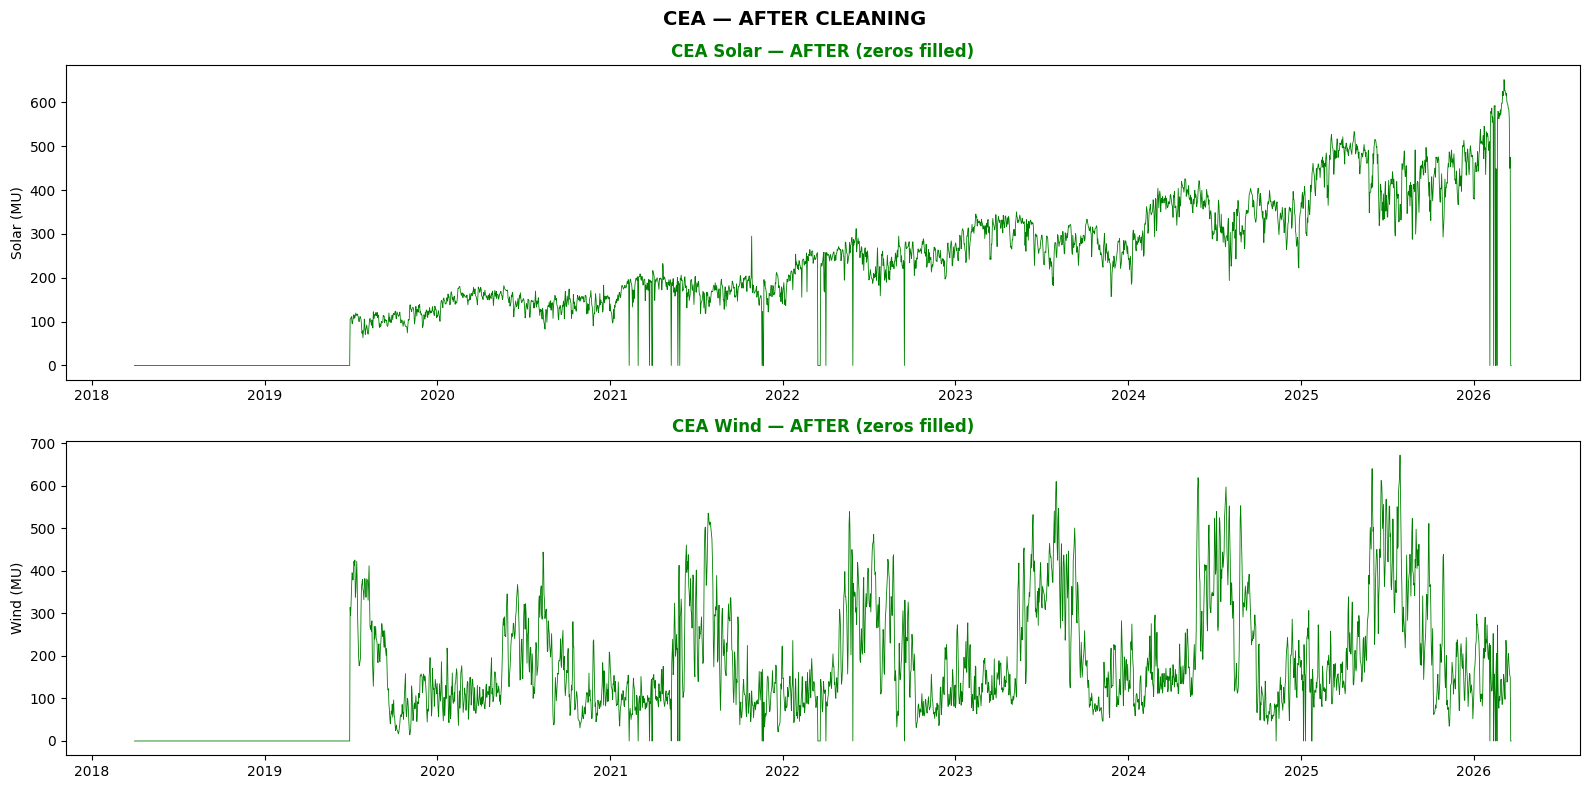

 Saved: 00_AFTER_cleaning_cea.png


In [34]:
# CEA AFTER CLEANING VISUALIZATION
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(cea.index, cea['Solar'], color='green', linewidth=0.6)
axes[0].set_title('CEA Solar — AFTER (zeros filled)',
                  fontweight='bold', color='green')
axes[0].set_ylabel('Solar (MU)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(cea.index, cea['Wind'], color='green', linewidth=0.6)
axes[1].set_title('CEA Wind — AFTER (zeros filled)',
                  fontweight='bold', color='green')
axes[1].set_ylabel('Wind (MU)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('CEA — AFTER CLEANING', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '00_AFTER_cleaning_cea.png'), dpi=150)
plt.show()
print(" Saved: 00_AFTER_cleaning_cea.png")
